# Phase 1 pipeline overview — Rooftop Solar Potential

**What this notebook is:** the *map* of the whole pipeline, so the individual stage
notebooks (`01_...`, `02_...`) make sense in context. It is deliberately light on code —
one small worked example — and heavy on the *why*.

**The one-line goal of the project:** score **every rooftop** in a city for solar
suitability from public data, then roll those per-roof numbers up to neighbourhood /
census-tract choropleths (the Google Project Sunroof pattern). Phase 1 does this for a
single DC neighbourhood — **Glover Park** — end to end, rough but real.

> Source of truth is `docs/Rooftop_Solar_Project_Plan.pdf`; section numbers like *(risks §8)*
> below point into the docs in `docs/`.

## The pipeline as a data-flow

Seven stages. Each one's *output* is the next one's *input*. The code module for each is in
`src/rooftop_solar/`.

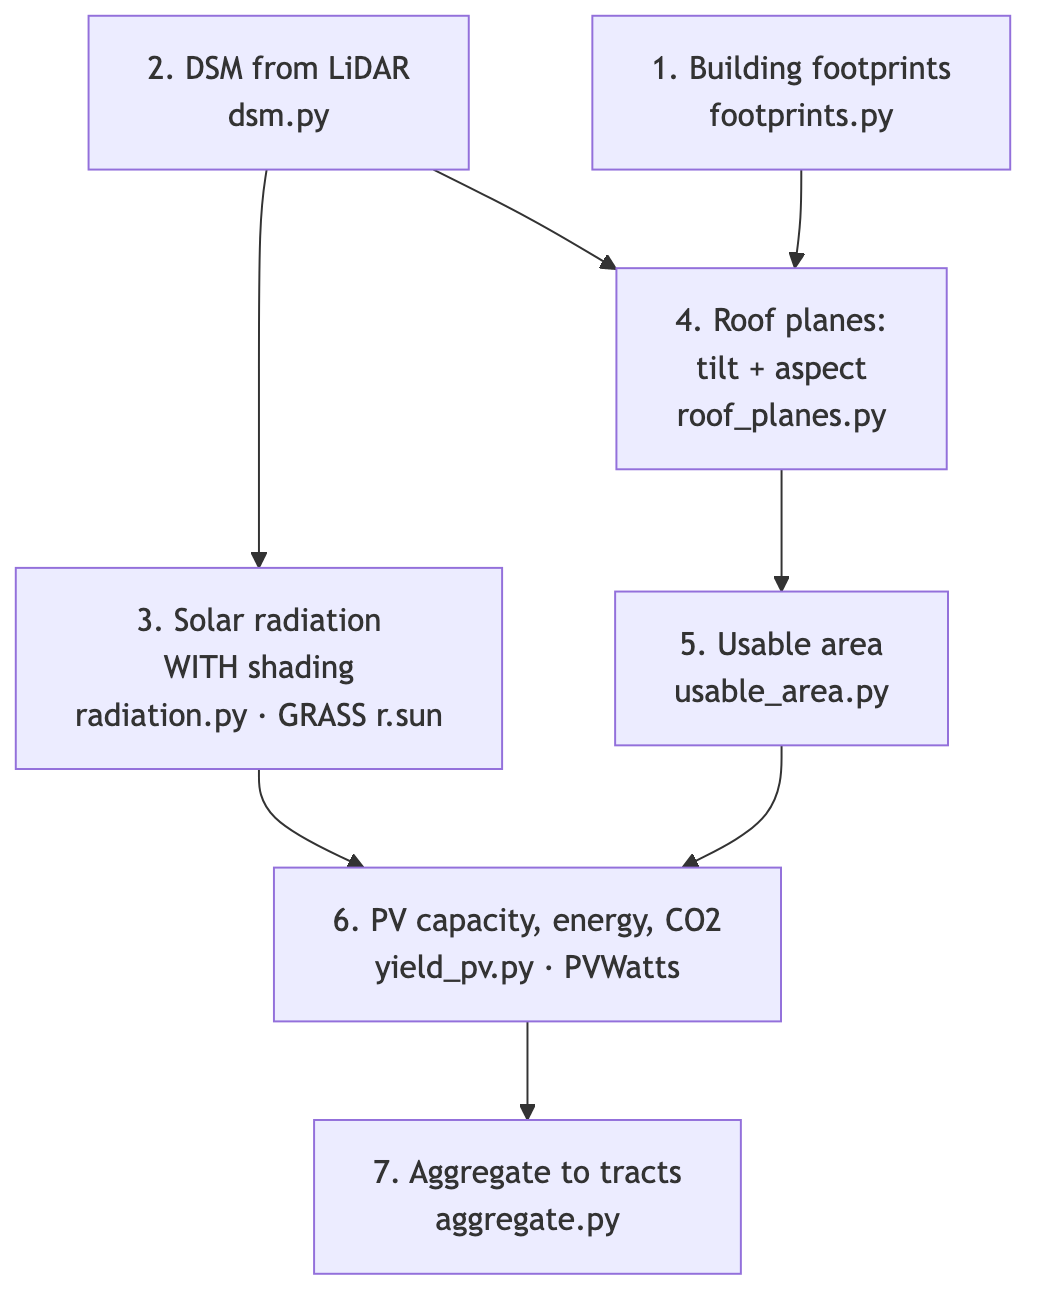

<sub>Diagram rendered from [`diagrams/00_pipeline.mmd`](diagrams/00_pipeline.mmd) — GitHub's notebook viewer doesn't render mermaid in markdown cells, so the source is kept as an editable `.mmd` file (re-render: `npx @mermaid-js/mermaid-cli -i diagrams/00_pipeline.mmd -o diagrams/00_pipeline.png -b white -s 2`).</sub>

| # | Stage | Input | Output | Module |
|---|---|---|---|---|
| 1 | Building footprints | study-area polygon | roof outline polygons | `footprints.py` |
| 2 | DSM from LiDAR | study-area polygon | surface-elevation raster | `dsm.py` |
| 3 | Solar radiation | DSM | per-cell annual insolation **(shaded)** | `radiation.py` |
| 4 | Roof planes | footprints + DSM | per-roof slope + aspect | `roof_planes.py` |
| 5 | Usable area | roof planes | panel-able m² per roof | `usable_area.py` |
| 6 | PV yield | usable area + insolation | kW, kWh/yr, CO₂/yr per roof | `yield_pv.py` |
| 7 | Aggregate | per-roof results + tracts | per-tract summaries | `aggregate.py` |

**Where we are right now:** stages 1–2 are built and verified (see `01_footprints_and_dsm`).
Stage 3 (radiation) is next — it is the trickiest, because of the shading traps below.

## Two modelling modes, one downstream (architecture §5)

Only the **geometry front-end** changes; everything from radiation onward is identical.

- **LiDAR per-roof** *(v1 default, Washington DC).* Clip the DSM/point cloud per building and
  fit individual roof planes → real per-roof slope, aspect, obstructions. High resolution.
- **Block-model / LOD-1** *(fallback + heritage).* Extrude each footprint to one height. No
  roof detail, but still supports inter-building shading. This is the mode the 2024 SIH
  prototype ran on, and the path for cities where LiDAR isn't available (Phase 3, India).

## The four shading traps (risks §8) — easy to get wrong, hard to notice

Inter-building shading is where naive rooftop-solar estimates silently break. All four of
these produce *plausible-looking* numbers that are wrong:

1. **Use the DSM, never the DTM.** The DTM is bare earth — *no buildings* — so it zeroes out
   every building-on-building shadow. (We prove this visually in `01`.)
2. **Buffer the AOI.** A tall building just *outside* your frame still shades roofs on the
   south edge inside it. Fetch a buffered area, report the core.
3. **Set a big enough shadow search distance** in `r.sun` — downtown, far tall towers still
   cast shadows.
4. **Don't let PVWatts undo the shading.** PVWatts assumes an *unshaded* horizon. Feed it the
   shading-adjusted insolation (or a shading loss), never the raw location value — or you
   throw away everything stages 2–3 worked to compute.

Trap 4 is demonstrated in the worked example below (the `shading_retained` line).

## The whole chain on one toy roof

The pipeline runs the maths below for **every roof plane** in the neighbourhood. Doing it
once, by hand, makes the end-to-end shape concrete before we scale it. The numbers are
representative-for-DC, not a real roof — the point is the *chain*, and where each stage plugs
in.

In [1]:
# One roof, end to end. Each block is labelled with the pipeline stage it stands in for.

# --- Stage 1 (footprints): the building outline gives us an area ----------------
footprint_area_m2 = 120.0        # a typical row-house footprint

# --- Stage 4 (roof planes): a pitched roof has 2+ faces; take the sun-facing one -
plane_tilt_deg    = 25.0         # slope of the roof plane
plane_azimuth_deg = 180.0        # 180 deg = due south (best in N. hemisphere)

# --- Stage 5 (usable area): strip setbacks, edges, chimneys, wrong-facing area ---
usable_fraction = 0.34           # ~ one good roof face after exclusions
usable_area_m2  = footprint_area_m2 * usable_fraction
print(f"usable panel area  : {usable_area_m2:6.1f}  m^2")

# --- Stage 6a (capacity): modern panels ~200 W per m^2 = 0.20 kW/m^2 -------------
power_density_kw_per_m2 = 0.20
capacity_kw = usable_area_m2 * power_density_kw_per_m2
print(f"installed capacity : {capacity_kw:6.2f}  kW")

# --- Stage 3 -> 6b (energy): 'specific yield' = kWh per kW per year for this ------
# location + tilt/azimuth. DC, a well-oriented plane ~ 1300 kWh/kW/yr (NLR PVWatts).
specific_yield_kwh_per_kw = 1300.0

# TRAP 4 (risks §8): PVWatts assumes an UNSHADED horizon. Stage 3 (r.sun over the
# DSM) measured that neighbours/trees cut THIS plane's sun by ~10%. Apply it here,
# or we silently over-count every roof.
shading_retained = 0.90          # 1.0 = open sky ; 0.90 = 10% lost to shadows

annual_energy_kwh = capacity_kw * specific_yield_kwh_per_kw * shading_retained
print(f"annual energy      : {annual_energy_kwh:6.0f}  kWh/yr")

# --- Stage 6c (CO2): kg CO2 avoided per kWh, from the regional grid mix ----------
grid_kg_co2_per_kwh = 0.35
annual_co2_offset_kg = annual_energy_kwh * grid_kg_co2_per_kwh
print(f"annual CO2 offset  : {annual_co2_offset_kg:6.0f}  kg/yr")

usable panel area  :   40.8  m^2
installed capacity :   8.16  kW
annual energy      :   9547  kWh/yr
annual CO2 offset  :   3342  kg/yr


**Read the chain:** footprint area → keep the usable fraction → convert m² to kW → multiply
by the location's specific yield → **knock off the shading** → convert kWh to CO₂.

Change one input and watch it ripple: drop `shading_retained` to `0.70` (a roof boxed in by
taller neighbours) and the energy and CO₂ fall ~22%. That single line is the entire reason
stages 2–3 exist — without a shaded DSM we would never know to apply it.

**Scaling up (stage 7):** the real pipeline computes this for tens of thousands of roof
planes, then spatial-joins them to census tracts and sums — turning per-roof kWh into a
neighbourhood choropleth with an equity lens.

## The honest weak link (risks §14.4)

**Stage 4 (roof-plane extraction) is the weakest link** — a wrong slope or aspect propagates
straight into kWh and CO₂. Phase 1 uses a RANSAC baseline; Phase 2 adds an ML segmentation
model (RoofN3D-trained) for planes *and* obstructions. Throughout, we **report uncertainty
rather than over-claim precision.**

## What's next

- **`01_footprints_and_dsm.ipynb`** — stages 1–2 hands-on: fetch real Glover Park footprints
  and a DSM, and *see* the DSM-vs-DTM trap.
- Then stage 3: solar radiation with GRASS `r.sun` (the shading engine).